# scikit-learn BBBP Baseline

This notebook provides the first end-to-end model notebook for the project.

Task: binary classification on BBBP
Strategy: character n-gram TF-IDF on SMILES plus logistic regression

Why this baseline first:
- no RDKit dependency required
- fully reproducible with the current environment
- provides a clean benchmark before chemistry-specific featurization

In [38]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42

In [39]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))
bbbp = pd.read_csv(DATA_DIR / "BBBP.csv")

print("Shape:", bbbp.shape)
display(bbbp.head())

Shape: (2050, 4)


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O


## Data Checks

Missing values by column:


num       0
name      0
p_np      0
smiles    0
dtype: int64

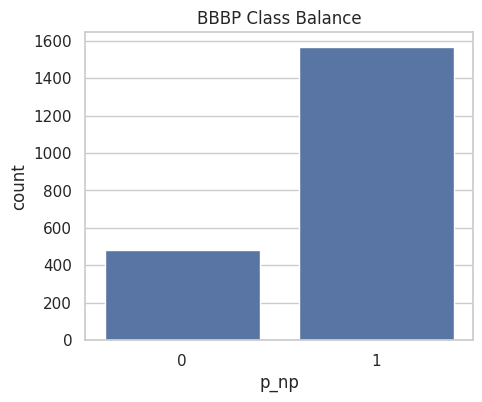

In [40]:
print("Missing values by column:")
display(bbbp.isna().sum())

plt.figure(figsize=(5, 4))
sns.countplot(data=bbbp, x="p_np")
plt.title("BBBP Class Balance")
plt.show()

In [41]:
X = bbbp["smiles"]
y = bbbp["p_np"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print("Train:", len(X_train), "Valid:", len(X_valid), "Test:", len(X_test))

Train: 1435 Valid: 307 Test: 308


## Model

We use a simple pipeline:
- character n-gram TF-IDF over SMILES strings
- logistic regression classifier

In [42]:
pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 5), min_df=2)),
        (
            "model",
            LogisticRegression(
                max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED
            ),
        ),
    ]
)

pipeline.fit(X_train, y_train)

valid_pred = pipeline.predict(X_valid)
valid_proba = pipeline.predict_proba(X_valid)[:, 1]

valid_metrics = pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": accuracy_score(y_valid, valid_pred),
            "f1": f1_score(y_valid, valid_pred),
            "roc_auc": roc_auc_score(y_valid, valid_proba),
        }
    ]
)
display(valid_metrics.round(4))

,split,accuracy,f1,roc_auc
0,validation,0.8762,0.9159,0.9471


In [43]:
test_pred = pipeline.predict(X_test)
test_proba = pipeline.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame(
    [
        {
            "split": "test",
            "accuracy": accuracy_score(y_test, test_pred),
            "f1": f1_score(y_test, test_pred),
            "roc_auc": roc_auc_score(y_test, test_proba),
        }
    ]
)
display(test_metrics.round(4))
print(classification_report(y_test, test_pred, digits=4))

,split,accuracy,f1,roc_auc
0,test,0.8766,0.9174,0.9403


              precision    recall  f1-score   support

           0     0.7108    0.8082    0.7564        73
           1     0.9378    0.8979    0.9174       235

    accuracy                         0.8766       308
   macro avg     0.8243    0.8530    0.8369       308
weighted avg     0.8840    0.8766    0.8792       308



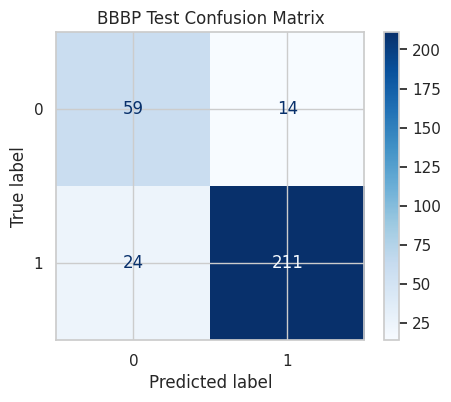

In [44]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=ax, cmap="Blues")
ax.set_title("BBBP Test Confusion Matrix")
plt.show()

## Next Steps

After this baseline:
1. compare against random forest or gradient boosting on engineered features
2. add a PyTorch MLP using a matched split
3. add a TensorFlow baseline using the same split and metric contract
4. later replace text features with chemistry-aware descriptors or graph features